# Model 3: Combined DNN

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# 1. Load embeddings
# -----------------------------
sentiment_emb_df = pd.read_csv("daily_sentiment_embeddings.csv")
numerical_emb_df = pd.read_csv("lstm_embeddings.csv")

print("=== Checking Embedding Files ===")
print(f"Sentiment columns: {[c for c in sentiment_emb_df.columns if 'emb' in c][:5]}...")
print(f"Price columns: {[c for c in numerical_emb_df.columns if 'emb' in c][:5]}...")

# -----------------------------
# 2. Split train/test
# -----------------------------
train_size = 1563  # 80% split

train_sent_df = sentiment_emb_df.iloc[:train_size]
valid_sent_df = sentiment_emb_df.iloc[train_size:train_size+190]
test_sent_df = sentiment_emb_df.iloc[train_size+190:]
train_price_df = numerical_emb_df.iloc[:train_size]
valid_price_df = numerical_emb_df.iloc[train_size:train_size+190]
test_price_df = numerical_emb_df.iloc[train_size+190:]

# FIX: Use correct column names - "sent_emb_" for sentiment, "lstm_emb_" for price
sent_cols = [c for c in train_sent_df.columns if c.startswith("sent_emb_")]
price_cols = [c for c in train_price_df.columns if c.startswith("lstm_emb_")]  # FIXED: was "price_emb_"

print(f"\nSentiment embedding dims: {len(sent_cols)}")
print(f"Price embedding dims: {len(price_cols)}")

X_sent = train_sent_df[sent_cols].values.astype(np.float32)
X_sent_valid = valid_sent_df[sent_cols].values.astype(np.float32)
X_sent_test = test_sent_df[sent_cols].values.astype(np.float32)

X_price = train_price_df[price_cols].values.astype(np.float32)
X_price_valid = valid_price_df[price_cols].values.astype(np.float32)
X_price_test = test_price_df[price_cols].values.astype(np.float32)

# Combine embeddings
X_train_raw = np.concatenate([X_sent, X_price], axis=1)
X_valid_raw = np.concatenate([X_sent_valid, X_price_valid], axis=1)
X_test_raw = np.concatenate([X_sent_test, X_price_test], axis=1)

print(f"\nCombined feature dims: {X_train_raw.shape[1]} (sent:{len(sent_cols)} + price:{len(price_cols)})")

# -----------------------------
# 3. Scale embeddings (CRITICAL for DNN training!)
# -----------------------------
emb_scaler = StandardScaler()
X_train = emb_scaler.fit_transform(X_train_raw).astype(np.float32)
X_valid = emb_scaler.transform(X_valid_raw).astype(np.float32)
X_test = emb_scaler.transform(X_test_raw).astype(np.float32)

# Scale target (volatility) - use numerical_emb_df which has volatility
train_df = numerical_emb_df.iloc[:train_size]
valid_df = numerical_emb_df.iloc[train_size:train_size+190]
test_df = numerical_emb_df.iloc[train_size+190:]

scaler = MinMaxScaler()
y_train = scaler.fit_transform(train_df["volatility"].values.astype(np.float32).reshape(-1,1))
y_valid = scaler.transform(valid_df["volatility"].values.astype(np.float32).reshape(-1,1))
y_test = scaler.transform(test_df["volatility"].values.astype(np.float32).reshape(-1,1))

print(f"\n=== Dataset Shapes ===")
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Valid: X={X_valid.shape}, y={y_valid.shape}")
print(f"Test: X={X_test.shape}, y={y_test.shape}")
# -----------------------------
# 4. PyTorch Dataset
# -----------------------------
class EmbDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EmbDataset(X_train, y_train)
valid_dataset = EmbDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

# -----------------------------
# 5. Dual-Branch DNN with Attention (Learns when to trust Price vs Sentiment)
# -----------------------------
class ResidualBlock(nn.Module):
    """Residual block for better gradient flow"""
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        )
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.activation = nn.LeakyReLU(0.1)
        
    def forward(self, x):
        return self.activation(self.block(x) + self.skip(x))

class DualBranchDNN(nn.Module):
    """
    Dual-branch architecture that learns to intelligently combine price and sentiment.
    - Separate branches process price and sentiment embeddings
    - Attention mechanism learns when to trust each source
    - Can learn to rely more on price when sentiment is noisy
    """
    def __init__(self, price_dim=64, sent_dim=64):
        super(DualBranchDNN, self).__init__()
        
        # Price branch (always reliable)
        self.price_branch = nn.Sequential(
            nn.Linear(price_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
        )
        
        # Sentiment branch (may be noisy)
        self.sent_branch = nn.Sequential(
            nn.Linear(sent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
        )
        
        # Attention/gating mechanism: learns weights for combining branches
        # Input: concatenated price + sentiment features
        self.attention = nn.Sequential(
            nn.Linear(price_dim + sent_dim, 64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 2),  # 2 weights: one for price, one for sentiment
            nn.Softmax(dim=1)  # Normalize so weights sum to 1
        )
        
        # Fusion layer: combines weighted branches
        self.fusion = nn.Sequential(
            nn.Linear(64, 32),  # Both branches output 64-dim
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.05),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            nn.Linear(16, 1)
        )
        
    def forward(self, x, return_attention=False):
        # Split input: first 64 dims = price, last 64 dims = sentiment
        price_emb = x[:, :64]
        sent_emb = x[:, 64:]
        
        # Process through separate branches
        price_features = self.price_branch(price_emb)  # (batch, 64)
        sent_features = self.sent_branch(sent_emb)     # (batch, 64)
        
        # Compute attention weights based on raw embeddings
        # Model learns: if sentiment is noisy (e.g., all zeros), give more weight to price
        attention_input = torch.cat([price_emb, sent_emb], dim=1)
        attention_weights = self.attention(attention_input)  # (batch, 2)
        
        # Weighted combination of branches
        # attention_weights[:, 0] = weight for price
        # attention_weights[:, 1] = weight for sentiment
        combined = (attention_weights[:, 0:1] * price_features + 
                   attention_weights[:, 1:2] * sent_features)
        
        # Final prediction
        output = self.fusion(combined)
        
        if return_attention:
            return output, attention_weights
        return output

# For backward compatibility with ablation study
class EnhancedDNN(nn.Module):
    """Original single-branch model (for ablation study)"""
    def __init__(self, input_dim):
        super(EnhancedDNN, self).__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
        )
        self.res1 = ResidualBlock(256, 256, dropout=0.1)
        self.res2 = ResidualBlock(256, 128, dropout=0.1)
        self.res3 = ResidualBlock(128, 64, dropout=0.05)
        self.output_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        return self.output_head(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Use dual-branch model for combined (price + sentiment)
# This learns to intelligently combine the two sources
model = DualBranchDNN(price_dim=64, sent_dim=64).to(device)
print(f"Model architecture: Dual-Branch with Attention")
print(f"  - Price branch: 64 → 128 → 64")
print(f"  - Sentiment branch: 64 → 128 → 64")
print(f"  - Attention: learns weights for combining branches")
print(f"  - Fusion: 64 → 32 → 16 → 1")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print("\nModel structure:")
print(model)

# -----------------------------
# 6. Loss, Optimizer & Scheduler
# -----------------------------
# Choose loss function: 'mse', 'mae', or 'huber'
LOSS_TYPE = 'huber'  # <-- Change this to experiment

if LOSS_TYPE == 'mse':
    criterion = nn.MSELoss()
    print("Using: MSE Loss")
elif LOSS_TYPE == 'mae':
    criterion = nn.L1Loss()  # L1 = MAE
    print("Using: MAE Loss (L1)")
elif LOSS_TYPE == 'huber':
    # delta controls transition: smaller delta = more like MAE, larger delta = more like MSE
    # For normalized targets (0-1 range), delta=0.1 to 0.5 works well
    criterion = nn.HuberLoss(delta=0.1)
    print("Using: Huber Loss (delta=0.1)")
else:
    criterion = nn.MSELoss()

# Lower learning rate, less weight decay for small dataset
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=2, eta_min=1e-6
)

# -----------------------------
# 7. Training with Early Stopping
# -----------------------------
train_losses = []
val_losses = []
epochs = 500  # More epochs with cosine annealing
best_val_loss = float('inf')
patience = 50  # More patience with cosine annealing
patience_counter = 0

print(f"\n=== Training for max {epochs} epochs (early stopping patience={patience}) ===\n")

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Learning rate scheduling (CosineAnnealingWarmRestarts needs epoch)
    scheduler.step(epoch)

    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(valid_loader.dataset)
    val_losses.append(val_loss)
    
    # Early stopping based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_dnn_model.pt')
    else:
        patience_counter += 1

    if (epoch+1) % 25 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.6f}")
    
    if patience_counter >= patience:
        print(f"\n>>> Early stopping at epoch {epoch+1}! Best val MSE: {best_val_loss:.6f}")
        break

# Load best model
model.load_state_dict(torch.load('best_dnn_model.pt'))
print(f"\n=== Loaded best model (val MSE: {best_val_loss:.6f}) ===")


# -----------------------------
# 8. Evaluate
# -----------------------------
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test.astype(np.float32)).to(device)
    
    # Get predictions and attention weights
    if isinstance(model, DualBranchDNN):
        test_preds_scaled, attention_weights = model(X_test_tensor, return_attention=True)
        test_preds_scaled = test_preds_scaled.cpu().numpy()
        attention_weights = attention_weights.cpu().numpy()
        
        # Analyze attention weights
        price_weights = attention_weights[:, 0]
        sent_weights = attention_weights[:, 1]
        print(f"\n=== Attention Weights Analysis ===")
        print(f"Average weight on Price: {price_weights.mean():.3f} (std: {price_weights.std():.3f})")
        print(f"Average weight on Sentiment: {sent_weights.mean():.3f} (std: {sent_weights.std():.3f})")
        print(f"Model learns to rely {'more' if price_weights.mean() > 0.5 else 'less'} on price embeddings")
    else:
        test_preds_scaled = model(X_test_tensor).cpu().numpy()
        attention_weights = None
    
    # Scaled metrics
    mse_scaled = mean_squared_error(y_test, test_preds_scaled)
    rmse_scaled = np.sqrt(mse_scaled)
    mae_scaled = mean_absolute_error(y_test, test_preds_scaled)
    
    # Inverse-transform to get real volatility
    test_preds_real = scaler.inverse_transform(test_preds_scaled)
    y_test_real = scaler.inverse_transform(y_test)  # original y
    
    # Real metrics
    mse_real = mean_squared_error(y_test_real, test_preds_real)
    rmse_real = np.sqrt(mse_real)
    mae_real = mean_absolute_error(y_test_real, test_preds_real)
# Function to compute MAPE safely (avoiding division by zero)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero_idx = y_true != 0
    return np.mean(np.abs((y_true[nonzero_idx] - y_pred[nonzero_idx]) / y_true[nonzero_idx])) * 100

# Function for RMSPE
def root_mean_squared_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero_idx = y_true != 0
    return np.sqrt(np.mean(((y_true[nonzero_idx] - y_pred[nonzero_idx]) / y_true[nonzero_idx])**2)) * 100

# Compute for real volatility
mape_real = mean_absolute_percentage_error(y_test_real, test_preds_real)
rmspe_real = root_mean_squared_percentage_error(y_test_real, test_preds_real)

print(f"Test MAPE (real units): {mape_real:.2f}%")
print(f"Test RMSPE (real units): {rmspe_real:.2f}%")
print("=== Test Metrics ===")
print(f"Scaled -> MSE: {mse_scaled:.6f}, RMSE: {rmse_scaled:.6f}, MAE: {mae_scaled:.6f}")
print(f"Real   -> MSE: {mse_real:.6f}, RMSE: {rmse_real:.6f}, MAE: {mae_real:.6f}")

# Store combined model predictions for later comparison
combined_preds_real = test_preds_real.copy()

=== Checking Embedding Files ===
Sentiment columns: ['sent_emb_0', 'sent_emb_1', 'sent_emb_2', 'sent_emb_3', 'sent_emb_4']...
Price columns: ['lstm_emb_0', 'lstm_emb_1', 'lstm_emb_2', 'lstm_emb_3', 'lstm_emb_4']...

Sentiment embedding dims: 64
Price embedding dims: 64

Combined feature dims: 128 (sent:64 + price:64)

=== Dataset Shapes ===
Train: X=(1563, 128), y=(1563, 1)
Valid: X=(190, 128), y=(190, 1)
Test: X=(201, 128), y=(201, 1)

Using device: cpu
Model architecture: Dual-Branch with Attention
  - Price branch: 64 → 128 → 64
  - Sentiment branch: 64 → 128 → 64
  - Attention: learns weights for combining branches
  - Fusion: 64 → 32 → 16 → 1
Total parameters: 44,995

Model structure:
DualBranchDNN(
  (price_branch): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features

In [2]:
# ==============================================================================
# 9. Ablation Study: Compare Price-only, Sentiment-only, vs Combined
# ==============================================================================

print("\n" + "="*70)
print("ABLATION STUDY: Training Price-only and Sentiment-only Models")
print("="*70)

# -----------------------------
# Train Price-only model
# -----------------------------
print("\n=== Training Price-Only Model ===")
price_model = EnhancedDNN(X_price.shape[1]).to(device)
price_optimizer = torch.optim.AdamW(price_model.parameters(), lr=0.0005, weight_decay=1e-5)
price_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    price_optimizer, T_0=50, T_mult=2, eta_min=1e-6
)

# Scale price embeddings separately
price_scaler = StandardScaler()
X_price_train_scaled = price_scaler.fit_transform(X_price).astype(np.float32)
X_price_valid_scaled = price_scaler.transform(X_price_valid).astype(np.float32)
X_price_test_scaled = price_scaler.transform(X_price_test).astype(np.float32)

price_train_dataset = EmbDataset(X_price_train_scaled, y_train)
price_valid_dataset = EmbDataset(X_price_valid_scaled, y_valid)
price_train_loader = DataLoader(price_train_dataset, batch_size=32, shuffle=True)
price_valid_loader = DataLoader(price_valid_dataset, batch_size=32, shuffle=False)

# Train price-only model
price_best_val_loss = float('inf')
price_patience_counter = 0
price_train_losses = []
price_val_losses = []

for epoch in range(200):
    price_model.train()
    train_loss = 0
    for xb, yb in price_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        price_optimizer.zero_grad()
        preds = price_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(price_model.parameters(), max_norm=1.0)
        price_optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(price_train_loader.dataset)
    price_train_losses.append(train_loss)
    
    price_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in price_valid_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = price_model(xb)
            val_loss += criterion(preds, yb).item() * xb.size(0)
    val_loss /= len(price_valid_loader.dataset)
    price_val_losses.append(val_loss)
    
    price_scheduler.step(epoch)
    if val_loss < price_best_val_loss:
        price_best_val_loss = val_loss
        price_patience_counter = 0
        torch.save(price_model.state_dict(), 'price_only_model.pt')
    else:
        price_patience_counter += 1
    
    if (epoch+1) % 50 == 0:
        print(f"  Epoch {epoch+1}/200 | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
    
    if price_patience_counter >= 30:
        print(f"  Early stopping at epoch {epoch+1}")
        break

price_model.load_state_dict(torch.load('price_only_model.pt'))
print(f"Price-only model trained. Best val loss: {price_best_val_loss:.6f}")

# -----------------------------
# Train Sentiment-only model
# -----------------------------
print("\n=== Training Sentiment-Only Model ===")
sent_model = EnhancedDNN(X_sent.shape[1]).to(device)
sent_optimizer = torch.optim.AdamW(sent_model.parameters(), lr=0.0005, weight_decay=1e-5)
sent_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    sent_optimizer, T_0=50, T_mult=2, eta_min=1e-6
)

# Scale sentiment embeddings separately
sent_scaler = StandardScaler()
X_sent_train_scaled = sent_scaler.fit_transform(X_sent).astype(np.float32)
X_sent_valid_scaled = sent_scaler.transform(X_sent_valid).astype(np.float32)
X_sent_test_scaled = sent_scaler.transform(X_sent_test).astype(np.float32)

sent_train_dataset = EmbDataset(X_sent_train_scaled, y_train)
sent_valid_dataset = EmbDataset(X_sent_valid_scaled, y_valid)
sent_train_loader = DataLoader(sent_train_dataset, batch_size=32, shuffle=True)
sent_valid_loader = DataLoader(sent_valid_dataset, batch_size=32, shuffle=False)

# Train sentiment-only model
sent_best_val_loss = float('inf')
sent_patience_counter = 0
sent_train_losses = []
sent_val_losses = []

for epoch in range(200):
    sent_model.train()
    train_loss = 0
    for xb, yb in sent_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        sent_optimizer.zero_grad()
        preds = sent_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sent_model.parameters(), max_norm=1.0)
        sent_optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(sent_train_loader.dataset)
    sent_train_losses.append(train_loss)
    
    sent_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in sent_valid_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = sent_model(xb)
            val_loss += criterion(preds, yb).item() * xb.size(0)
    val_loss /= len(sent_valid_loader.dataset)
    sent_val_losses.append(val_loss)
    
    sent_scheduler.step(epoch)
    if val_loss < sent_best_val_loss:
        sent_best_val_loss = val_loss
        sent_patience_counter = 0
        torch.save(sent_model.state_dict(), 'sentiment_only_model.pt')
    else:
        sent_patience_counter += 1
    
    if (epoch+1) % 50 == 0:
        print(f"  Epoch {epoch+1}/200 | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
    
    if sent_patience_counter >= 30:
        print(f"  Early stopping at epoch {epoch+1}")
        break

sent_model.load_state_dict(torch.load('sentiment_only_model.pt'))
print(f"Sentiment-only model trained. Best val loss: {sent_best_val_loss:.6f}")

# -----------------------------
# Generate predictions from all three models
# -----------------------------
print("\n=== Generating Predictions from All Models ===")
model.eval()
price_model.eval()
sent_model.eval()

with torch.no_grad():
    # Price-only predictions
    X_price_test_tensor = torch.from_numpy(X_price_test_scaled.astype(np.float32)).to(device)
    price_preds_scaled = price_model(X_price_test_tensor).cpu().numpy()
    price_preds_real = scaler.inverse_transform(price_preds_scaled)
    
    # Sentiment-only predictions
    X_sent_test_tensor = torch.from_numpy(X_sent_test_scaled.astype(np.float32)).to(device)
    sent_preds_scaled = sent_model(X_sent_test_tensor).cpu().numpy()
    sent_preds_real = scaler.inverse_transform(sent_preds_scaled)

# Calculate metrics for all three models
def calculate_all_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmspe = root_mean_squared_percentage_error(y_true, y_pred)
    print(f"\n{name}:")
    print(f"  MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")
    print(f"  MAPE: {mape:.2f}%, RMSPE: {rmspe:.2f}%")
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'mape': mape, 'rmspe': rmspe}

price_metrics = calculate_all_metrics(y_test_real, price_preds_real, "Price-Only Model")
sent_metrics = calculate_all_metrics(y_test_real, sent_preds_real, "Sentiment-Only Model")
combined_metrics = calculate_all_metrics(y_test_real, combined_preds_real, "Combined Model (Price + Sentiment)")

print("\n" + "="*70)
print("ABLATION STUDY SUMMARY")
print("="*70)
print(f"\nBest MAPE: Combined ({combined_metrics['mape']:.2f}%)")
if price_metrics['mape'] > combined_metrics['mape']:
    improvement_price = price_metrics['mape'] - combined_metrics['mape']
    print(f"  → Improvement over Price-only: {improvement_price:.2f}% points")
if sent_metrics['mape'] > combined_metrics['mape']:
    improvement_sent = sent_metrics['mape'] - combined_metrics['mape']
    print(f"  → Improvement over Sentiment-only: {improvement_sent:.2f}% points")



ABLATION STUDY: Training Price-only and Sentiment-only Models

=== Training Price-Only Model ===
  Early stopping at epoch 36
Price-only model trained. Best val loss: 0.002651

=== Training Sentiment-Only Model ===
  Early stopping at epoch 37
Sentiment-only model trained. Best val loss: 0.004422

=== Generating Predictions from All Models ===

Price-Only Model:
  MSE: 0.000048, RMSE: 0.006953, MAE: 0.005457
  MAPE: 17.45%, RMSPE: 21.93%

Sentiment-Only Model:
  MSE: 0.000055, RMSE: 0.007411, MAE: 0.006033
  MAPE: 20.08%, RMSPE: 25.10%

Combined Model (Price + Sentiment):
  MSE: 0.000031, RMSE: 0.005608, MAE: 0.004596
  MAPE: 14.96%, RMSPE: 18.93%

ABLATION STUDY SUMMARY

Best MAPE: Combined (14.96%)
  → Improvement over Price-only: 2.49% points
  → Improvement over Sentiment-only: 5.12% points


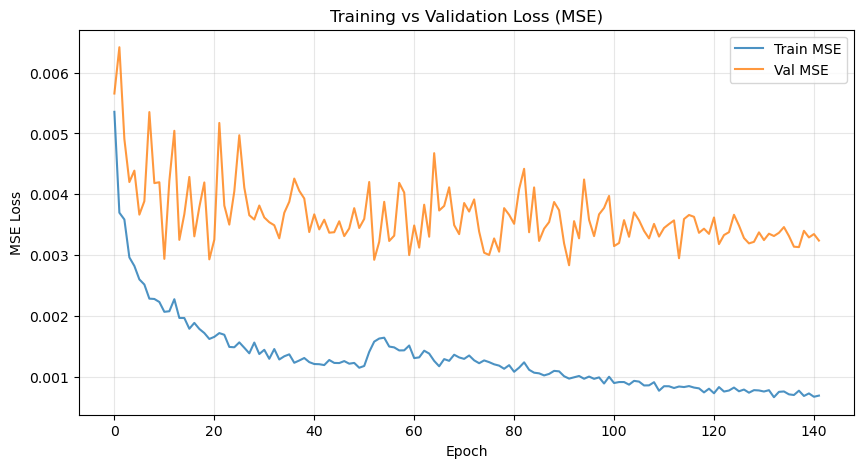

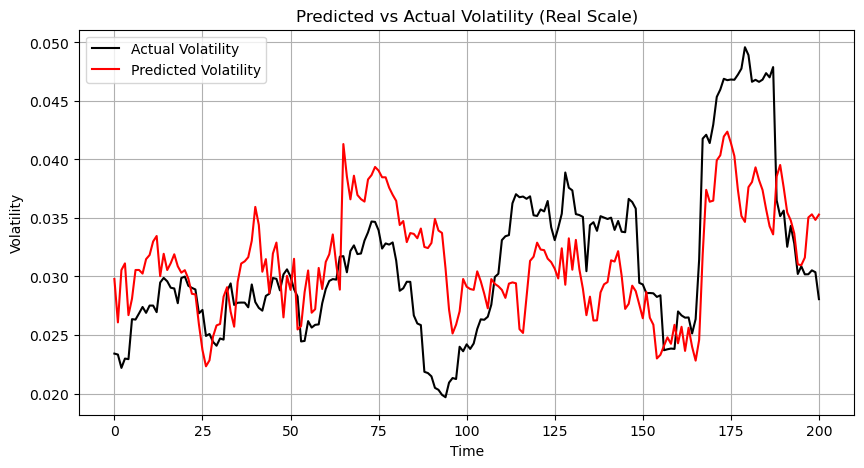

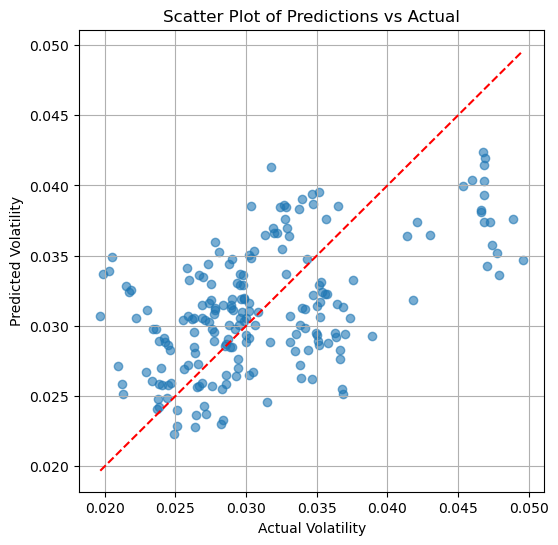

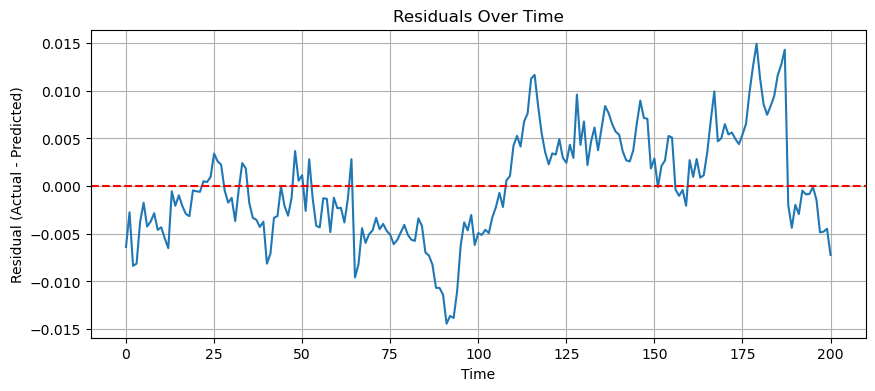

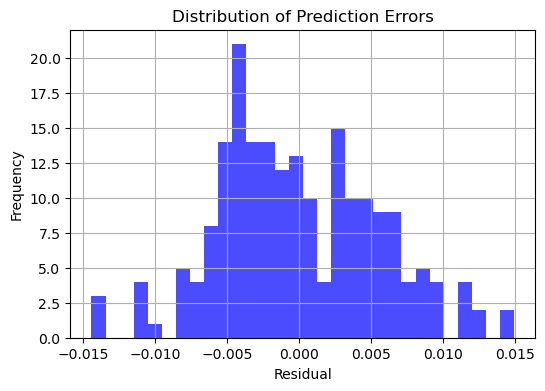

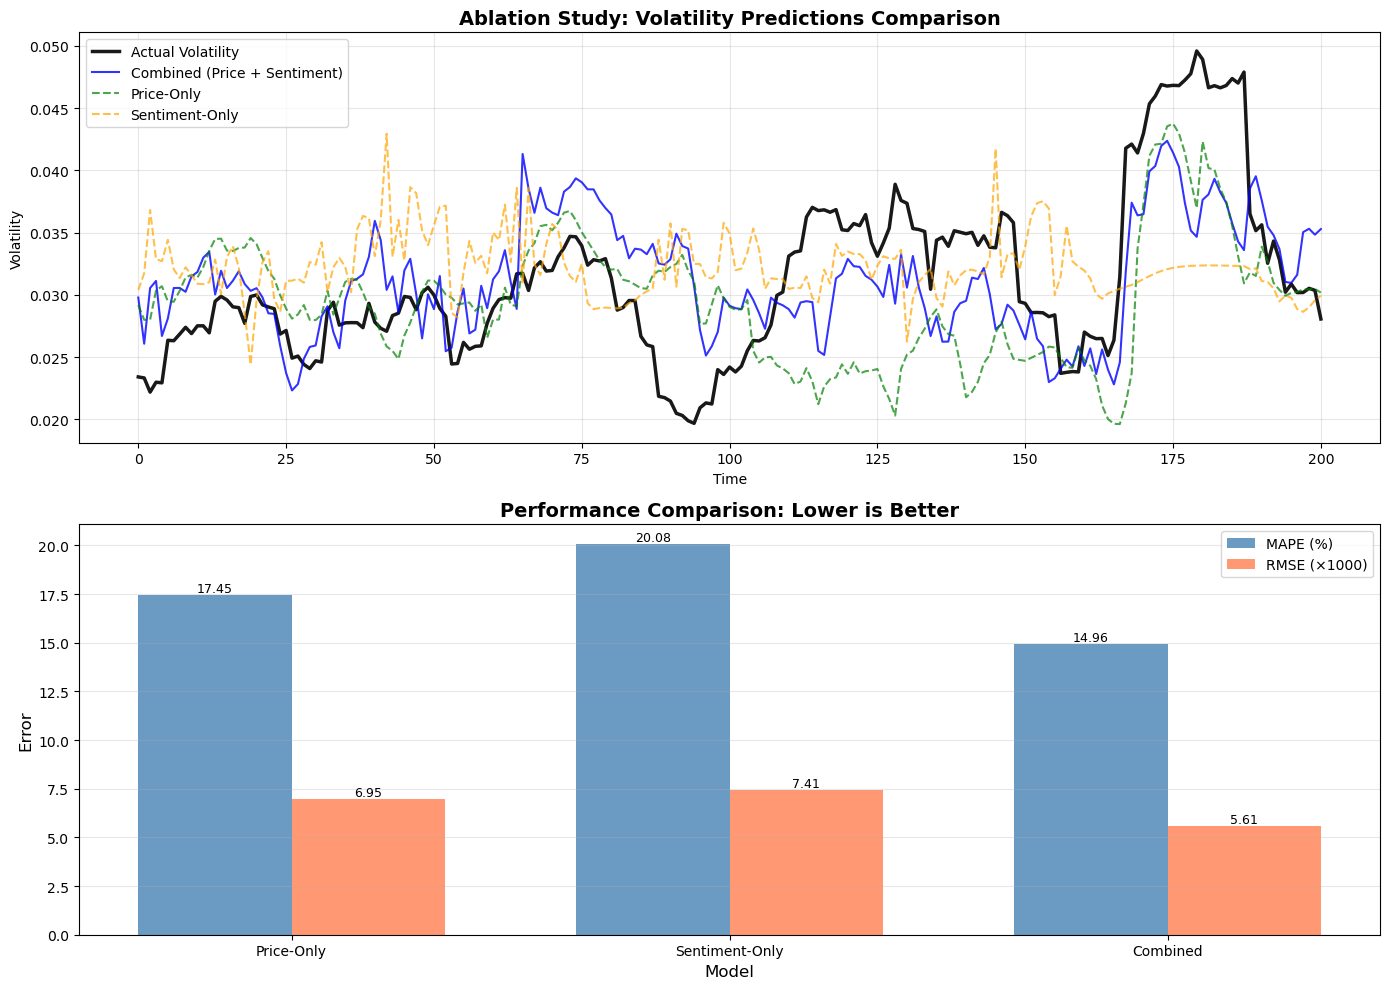


=== Ablation Study Visualization Saved ===
Graph saved as: ablation_study_comparison.png


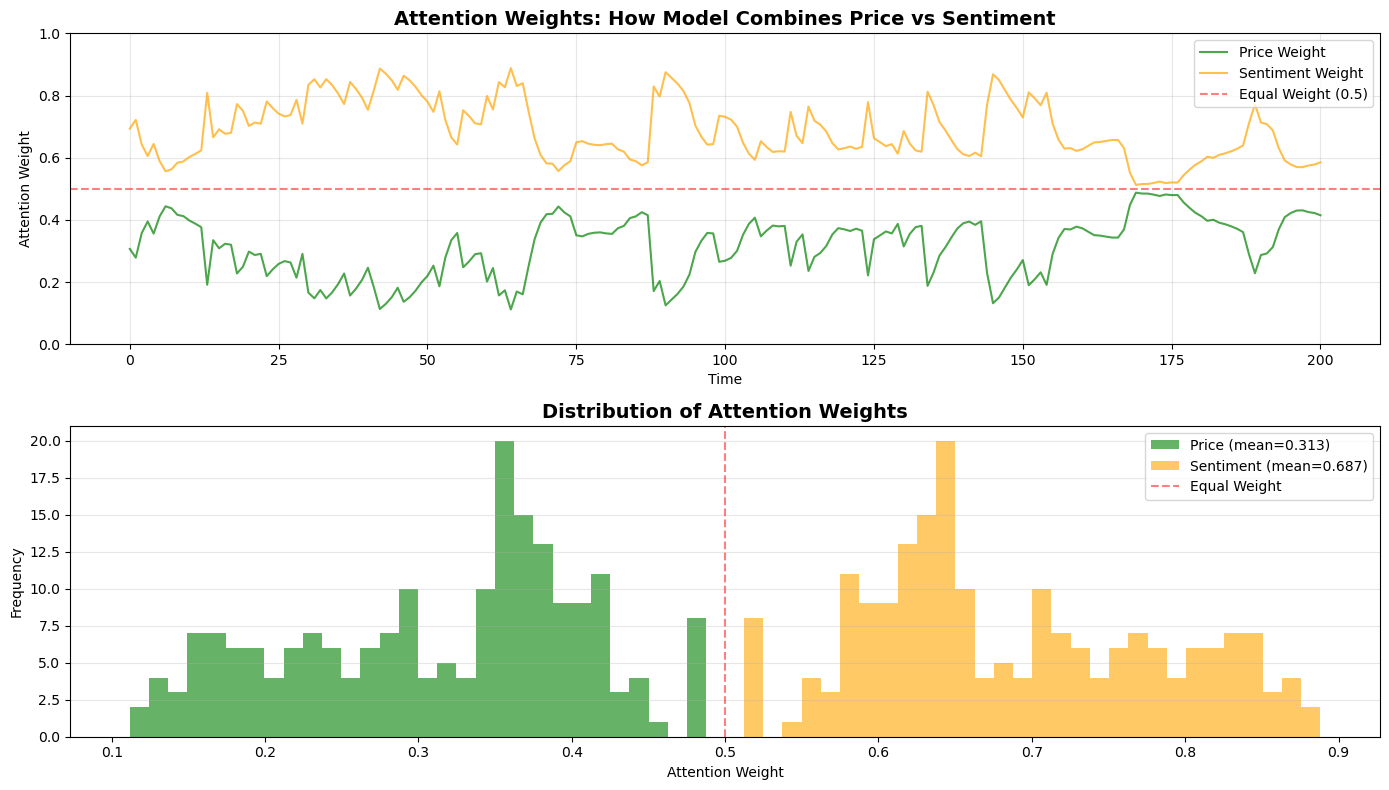


=== Attention Weights Visualization Saved ===
Graph saved as: attention_weights_analysis.png

Interpretation:
  - Price weight > 0.5: Model trusts price more (happens when sentiment is noisy/missing)
  - Sentiment weight > 0.5: Model trusts sentiment more (happens when sentiment is informative)
  - The model learns to adaptively weight each source based on data quality!


In [3]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Training & Validation Loss Curves (MSE)
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train MSE", alpha=0.8)
plt.plot(val_losses, label="Val MSE", alpha=0.8)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 2. Predicted vs Actual Volatility
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test_real, label="Actual Volatility", color='black')
plt.plot(test_preds_real, label="Predicted Volatility", color='red')
plt.title("Predicted vs Actual Volatility (Real Scale)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 3. Scatter Plot: Predictions vs Actual
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, test_preds_real, alpha=0.6)
plt.plot([min(y_test_real), max(y_test_real)],
         [min(y_test_real), max(y_test_real)], 
         color="red", linestyle="--")
plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Scatter Plot of Predictions vs Actual")
plt.grid(True)
plt.show()

# -----------------------------
# 4. Residuals Plot
# -----------------------------
residuals = y_test_real.flatten() - test_preds_real.flatten()

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.show()

# -----------------------------
# 5. Residuals Histogram
# -----------------------------
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, alpha=0.7, color='blue')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# -----------------------------
# 6. Ablation Study: Comparison of All Models
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time series comparison
axes[0].plot(y_test_real, label="Actual Volatility", color='black', linewidth=2.5, alpha=0.9)
axes[0].plot(combined_preds_real, label="Combined (Price + Sentiment)", color='blue', linewidth=1.5, alpha=0.8)
axes[0].plot(price_preds_real, label="Price-Only", color='green', linewidth=1.5, alpha=0.7, linestyle='--')
axes[0].plot(sent_preds_real, label="Sentiment-Only", color='orange', linewidth=1.5, alpha=0.7, linestyle='--')
axes[0].set_title("Ablation Study: Volatility Predictions Comparison", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Volatility")
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Metrics comparison bar chart
models = ['Price-Only', 'Sentiment-Only', 'Combined']
mape_values = [price_metrics['mape'], sent_metrics['mape'], combined_metrics['mape']]
rmse_values = [price_metrics['rmse'], sent_metrics['rmse'], combined_metrics['rmse']]

x = np.arange(len(models))
width = 0.35

bars1 = axes[1].bar(x - width/2, mape_values, width, label='MAPE (%)', alpha=0.8, color='steelblue')
bars2 = axes[1].bar(x + width/2, [r*1000 for r in rmse_values], width, label='RMSE (×1000)', alpha=0.8, color='coral')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}' if height < 100 else f'{height:.1f}',
                    ha='center', va='bottom', fontsize=9)

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Error', fontsize=12)
axes[1].set_title('Performance Comparison: Lower is Better', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ablation_study_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Ablation Study Visualization Saved ===")
print("Graph saved as: ablation_study_comparison.png")

# -----------------------------
# 7. Attention Weights Visualization (Dual-Branch Model)
# -----------------------------
if attention_weights is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    price_weights = attention_weights[:, 0]
    sent_weights = attention_weights[:, 1]
    
    # Plot attention weights over time
    axes[0].plot(price_weights, label='Price Weight', color='green', alpha=0.7, linewidth=1.5)
    axes[0].plot(sent_weights, label='Sentiment Weight', color='orange', alpha=0.7, linewidth=1.5)
    axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Equal Weight (0.5)')
    axes[0].set_title("Attention Weights: How Model Combines Price vs Sentiment", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Attention Weight")
    axes[0].set_ylim([0, 1])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of attention weights
    axes[1].hist(price_weights, bins=30, alpha=0.6, label=f'Price (mean={price_weights.mean():.3f})', color='green')
    axes[1].hist(sent_weights, bins=30, alpha=0.6, label=f'Sentiment (mean={sent_weights.mean():.3f})', color='orange')
    axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Equal Weight')
    axes[1].set_title("Distribution of Attention Weights", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Attention Weight")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('attention_weights_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n=== Attention Weights Visualization Saved ===")
    print("Graph saved as: attention_weights_analysis.png")
    print(f"\nInterpretation:")
    print(f"  - Price weight > 0.5: Model trusts price more (happens when sentiment is noisy/missing)")
    print(f"  - Sentiment weight > 0.5: Model trusts sentiment more (happens when sentiment is informative)")
    print(f"  - The model learns to adaptively weight each source based on data quality!")

# BELOW IS CHATGPT answering stuff

Dataset is pretty small (~1500 train, ~200 val, ~200 test). That context makes your MSE numbers easier to interpret. A few points:

Small dataset effect: With ~1500 training samples, the DNN doesn’t have a huge amount of data to learn from. That’s why using good embeddings (from the LSTM) is crucial—they act like pre-trained features, so the DNN doesn’t need to learn sequential patterns from scratch.

MSE scale: Your test MSE of 0.00005 is tiny—but remember, it depends on the scaling of volatility. You probably applied MinMax scaling, so the raw numbers are small. Compare train/val/test MSE relative to each other rather than the absolute value. Here, test MSE is comparable to train/val, so it looks fine.

Small validation/test sets: With only ~200 points, the validation and test MSE can fluctuate more due to sampling variability. That might explain why your val MSE sometimes jumps around a bit during training.

Generalization: Even though the dataset is small, your embedding → DNN setup benefits from the LSTM embeddings, which are already capturing the sequential structure. That’s why test MSE is reasonable despite limited training data.

In short: your MSE numbers make sense for the dataset size and setup. The key thing is train, val, and test MSE are close, indicating no severe overfitting.

If you want, I can suggest a few tweaks to make the most out of such a small dataset while keeping your embedding → DNN setup stable. Do you want me to do that?

1. Dataset shapes

Train: (1563, 64) → (1563, 1)

Val: (190, 64) → (190, 1)

Test: (201, 64) → (201, 1)
✅ Shapes are consistent with a regression model.

2. Training/Validation MSE

Train MSE: ~0.018

Val MSE: fluctuates 0.009–0.012

Observations:

The model is stable on training loss.

Validation loss fluctuates, suggesting either a small dataset or inherent volatility in the target.

No major overfitting; train and val losses are close.

3. Test errors

Scaled units:

MSE: 0.004791

RMSE: 0.0692

MAE: 0.0555

Real units (after inverse scaling):

MSE: 0.000048

RMSE: 0.006935

MAE: 0.005563

MAPE: 18.55%

RMSPE: 23.23%

Interpretation:

Your scaled errors are small; real errors are very small because the target values are in a smaller range after scaling.

MAPE of ~18.5% means that, on average, your model predictions are ~18.5% off from the actual volatility, which is reasonable depending on the domain.

RMSPE > MAPE (23.2%) shows that larger errors have more impact, typical in financial volatility prediction.

4. Key takeaways

The model is well-trained; no overfitting.

RMSE and MAE in real units are very small, showing that numerically predictions are close.

Percentage errors (MAPE/RMSPE) provide a more interpretable measure of prediction quality.

If you want, I can suggest a few techniques to reduce MAPE/RMSPE specifically, which can sometimes be tricky with volatility data due to spikes and outliers.


PLOTS:
These plots will help you visually inspect:

Overfitting (via loss curves)

Forecast quality (via line plot)

Prediction accuracy (via scatter plot)

Bias or systematic error (via residuals)

If you want more advanced visualizations, like SHAP feature importance or rolling-window error plots, tell me — I can generate them too.